# CPU Temperature Prediciton 

## Import Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib


## Load and Inspect Dataset

In [21]:
df_raw = pd.read_csv('kaggle_data.csv')

In [24]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Disk Write Speed (MB/s)  9702 non-null   float64
 1   Disk Read Speed (MB/s)   9800 non-null   float64
 2   CPU Usage (%)            9701 non-null   float64
 3   CPU Temperature (°C)     9800 non-null   float64
 4   Clock Speed (GHz)        9900 non-null   str    
 5   Cache Miss Rate (%)      9800 non-null   str    
 6   Power Consumption (W)    10000 non-null  float64
dtypes: float64(5), str(2)
memory usage: 547.0 KB


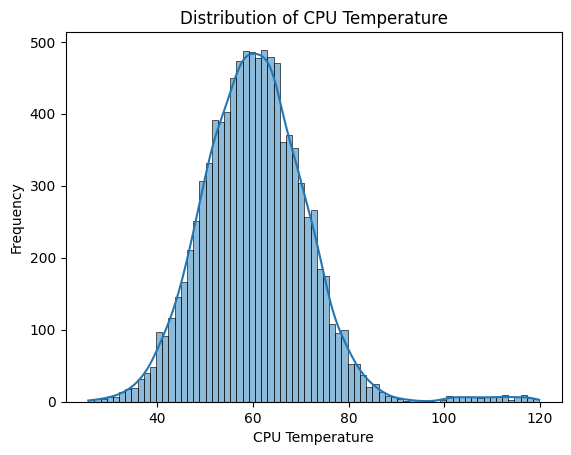

In [23]:
plt.figure()
sns.histplot(df_raw['CPU Temperature (°C)'], kde=True)
plt.title("Distribution of CPU Temperature")
plt.xlabel("CPU Temperature")
plt.ylabel("Frequency")
plt.show()

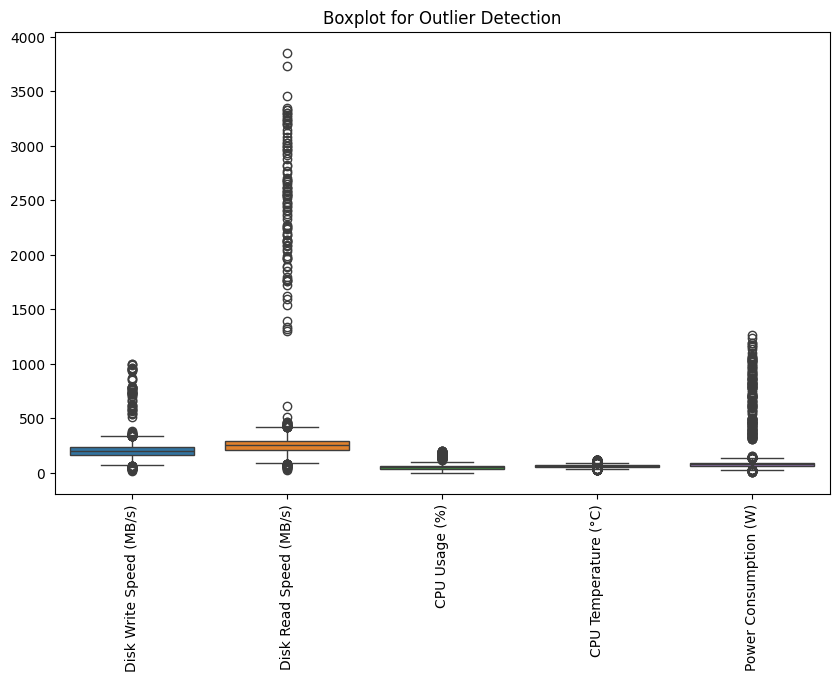

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_raw)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [5]:
display(df_raw.head())
display(df_raw.tail())
df_raw.info()

,timestamp,unix_time,cpu_load,ram_usage,ambient_temp,cpu_temp
0,2026-02-22 10:54:27,1.771738e+09,3.0,23.1,24.137455,38.875
1,2026-02-22 10:54:28,1.771738e+09,1.8,23.1,24.138009,38.750
2,2026-02-22 10:54:29,1.771738e+09,1.9,23.1,24.138563,38.625
3,2026-02-22 10:54:30,1.771738e+09,1.4,23.0,24.139118,38.500
4,2026-02-22 10:54:31,1.771738e+09,1.8,23.1,24.139672,38.375


,timestamp,unix_time,cpu_load,ram_usage,ambient_temp,cpu_temp
1795,2026-02-22 11:24:22,1.771740e+09,1.9,23.2,25.074870,40.875
1796,2026-02-22 11:24:23,1.771740e+09,1.7,23.2,25.075339,40.875
1797,2026-02-22 11:24:24,1.771740e+09,1.1,23.2,25.075807,40.875
1798,2026-02-22 11:24:25,1.771740e+09,1.2,23.2,25.076276,40.875
1799,2026-02-22 11:24:26,1.771740e+09,1.3,23.2,25.076744,40.875


<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     1800 non-null   str    
 1   unix_time     1800 non-null   float64
 2   cpu_load      1800 non-null   float64
 3   ram_usage     1800 non-null   float64
 4   ambient_temp  1800 non-null   float64
 5   cpu_temp      1800 non-null   float64
dtypes: float64(5), str(1)
memory usage: 84.5 KB


In [6]:
df_raw.duplicated().sum()

np.int64(0)

In [7]:
def removeOutliers(df, columns):
    df_clean = df.copy()
    initial_rows = len(df)

    for col in columns:
        if col in df_clean.columns:
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            df_clean = df_clean[(df_clean[col]>=lower_bound) & (df_clean[col]<=upper_bound)]

    return df_clean

column_to_clean = ['cpu_load', 'ram_usage', 'cpu_temp', 'ambient_temp']

df_clean = removeOutliers(df = df_raw, columns=column_to_clean)

In [8]:
df_clean = df_clean.sort_values('unix_time').reset_index(drop=True)

In [9]:
df_clean

,timestamp,unix_time,cpu_load,ram_usage,ambient_temp,cpu_temp
0,2026-02-22 10:54:27,1.771738e+09,3.0,23.1,24.137455,38.875
1,2026-02-22 10:54:28,1.771738e+09,1.8,23.1,24.138009,38.750
2,2026-02-22 10:54:29,1.771738e+09,1.9,23.1,24.138563,38.625
3,2026-02-22 10:54:30,1.771738e+09,1.4,23.0,24.139118,38.500
4,2026-02-22 10:54:31,1.771738e+09,1.8,23.1,24.139672,38.375
...,...,...,...,...,...,...
1792,2026-02-22 11:24:22,1.771740e+09,1.9,23.2,25.074870,40.875
1793,2026-02-22 11:24:23,1.771740e+09,1.7,23.2,25.075339,40.875
1794,2026-02-22 11:24:24,1.771740e+09,1.1,23.2,25.075807,40.875
1795,2026-02-22 11:24:25,1.771740e+09,1.2,23.2,25.076276,40.875


In [ ]:
def addFeatures(df_clean):
    df = df_clean.copy()

    # lag features
    df['cpu_temp_lag1'] = df['cpu_temp'].shift(1)
    df['cpu_temp_lag5'] = df['cpu_temp'].shift(5)
    df['cpu_load_lag1'] = df['cpu_load'].shift(1)
    df['cpu_load_lag5'] = df['cpu_load'].shift(5)
    df['cpu_load_lag10'] = df['cpu_load'].shift(10)

    # rate features
    df['temp_rate'] = df['cpu_temp'].diff()
    df['temp_accelaration'] = df['temp_rate'].diff()
    df['load_rate'] = df['cpu_load'].diff()

    # rolling features
    df['cpu_temp_roll10'] = df['cpu_temp'].rolling(window = 10).mean()
    df['cpu_load_roll10'] = df['cpu_load'].rolling(window = 10).mean()
    df['cpu_load_roll30'] = df['cpu_load'].rolling(window = 30).mean()
    df['cpu_load_std10'] = df['cpu_load'].rolling(window=10).std()

    # interaction features
    df['load_ambient_interaction'] = df['cpu_load'] * df['ambient_temp']
    df['thermal_stress'] = df['cpu_load'] * df['cpu_temp']
    df['temp_above_ambient'] = df['cpu_temp'] - df['ambient_temp']


    df = df.dropna()

    return df

df_features = addFeatures(df_clean)

In [11]:
print("\nSample of Engineered Features:")
print("="*100)

# Show subset of features
sample_cols = [
    'cpu_load', 'cpu_temp',
    'cpu_load_lag1', 'cpu_temp_lag1',
    'temp_rate', 'cpu_load_roll10',
    'thermal_stress'
]

display(df_features[sample_cols].head(20))

print("\nAll Feature Names:")
feature_cols = [col for col in df_features.columns 
                if col not in ['timestamp', 'unix_time', 'cpu_temp']]
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")
    
print(f"\nTotal features for training: {len(feature_cols)}")


Sample of Engineered Features:


,cpu_load,cpu_temp,cpu_load_lag1,cpu_temp_lag1,temp_rate,cpu_load_roll10,thermal_stress
29,9.7,41.000,13.8,41.000,0.000,8.47,397.7000
30,7.0,41.000,9.7,41.000,0.000,8.53,287.0000
31,9.8,41.000,7.0,41.000,0.000,8.80,401.8000
32,7.1,40.875,9.8,41.000,-0.125,8.86,290.2125
33,6.4,40.750,7.1,40.875,-0.125,8.89,260.8000
34,7.8,40.625,6.4,40.750,-0.125,9.08,316.8750
35,8.4,40.625,7.8,40.625,0.000,9.16,341.2500
36,7.7,40.500,8.4,40.625,-0.125,9.16,311.8500
37,7.5,40.500,7.7,40.500,0.000,8.52,303.7500
38,7.0,40.375,7.5,40.500,-0.125,7.84,282.6250



All Feature Names:
 1. cpu_load
 2. ram_usage
 3. ambient_temp
 4. cpu_temp_lag1
 5. cpu_temp_lag5
 6. cpu_load_lag1
 7. cpu_load_lag5
 8. cpu_load_lag10
 9. temp_rate
10. temp_accelaration
11. load_rate
12. cpu_temp_roll10
13. cpu_load_roll10
14. cpu_load_roll30
15. cpu_load_std10
16. load_ambient_interaction
17. thermal_stress
18. temp_above_ambient

Total features for training: 18


## Model Training and Evaluation


In [12]:
df_features['target_temp_5s'] = df_features['cpu_temp'].shift(-5)
df_features = df_features.dropna()

In [13]:
feature_cols = [
    col for col in df_features.columns
    if col not in ['timestamp', 'unix_time', 'cpu_temp', 'target_temp_5s']
]

X = df_features[feature_cols]
y = df_features['target_temp_5s']


In [14]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

### Linear Regression Model

In [15]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))

lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)

print("Linear Regression RMSE (Test):", lr_rmse)
print("Linear Regression Train R2:", lr_train_r2)
print("Linear Regression Test R2:", lr_test_r2)

Linear Regression RMSE (Test): 0.4206597479367911
Linear Regression Train R2: 0.9937368128719675
Linear Regression Test R2: 0.9960332488009841


### Decision Tree Regressor


In [16]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_test_pred))

dt_train_r2 = r2_score(y_train, dt_train_pred)
dt_test_r2 = r2_score(y_test, dt_test_pred)

print("Decision Tree RMSE (Test):", dt_rmse)
print("Decision Tree Train R2:", dt_train_r2)
print("Decision Tree Test R2:", dt_test_r2)

Decision Tree RMSE (Test): 1.3734861612435265
Decision Tree Train R2: 1.0
Decision Tree Test R2: 0.9577115640318694


### Random Forest Model

In [17]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)

print("Random Forest RMSE (Test):", rf_rmse)
print("Random Forest Train R2:", rf_train_r2)
print("Random Forest Test R2:", rf_test_r2)

Random Forest RMSE (Test): 0.6995380627523972
Random Forest Train R2: 0.9997604979984918
Random Forest Test R2: 0.9890302748297035


## Model Comparison

In [18]:
print("\nMODEL COMPARISON")
print("-----------------------------------------------------")
print("Linear Regression -> RMSE:", lr_rmse,
      " | Train R2:", lr_train_r2,
      " | Test R2:", lr_test_r2)

print("Decision Tree     -> RMSE:", dt_rmse,
      " | Train R2:", dt_train_r2,
      " | Test R2:", dt_test_r2)

print("Random Forest     -> RMSE:", rf_rmse,
      " | Train R2:", rf_train_r2,
      " | Test R2:", rf_test_r2)


MODEL COMPARISON
-----------------------------------------------------
Linear Regression -> RMSE: 0.4206597479367911  | Train R2: 0.9937368128719675  | Test R2: 0.9960332488009841
Decision Tree     -> RMSE: 1.3734861612435265  | Train R2: 1.0  | Test R2: 0.9577115640318694
Random Forest     -> RMSE: 0.6995380627523972  | Train R2: 0.9997604979984918  | Test R2: 0.9890302748297035


In [19]:
models = {
    "LinearRegression": (lr_model, lr_rmse),
    "DecisionTree": (dt_model, dt_rmse),
    "RandomForest": (rf_model, rf_rmse),
}

best_model_name = min(models, key=lambda x: models[x][1])
best_model = models[best_model_name][0]

print("Best model:", best_model_name)


Best model: LinearRegression


In [20]:
joblib.dump(best_model, "cpu_temp_predictor.pkl")
joblib.dump(feature_cols, "feature_columns.pkl")


['feature_columns.pkl']